In [2]:
from google.colab import files
import zipfile
import os

#загружаем архив
uploaded = files.upload()

#распаковка
zip_filename = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

#смотрим структуру
!ls -la /content/dataset/

Saving project-5-at-2026-05-16-11-37-ef7f5e1c.zip to project-5-at-2026-05-16-11-37-ef7f5e1c.zip
total 24
drwxr-xr-x 4 root root 4096 May 18 09:06 .
drwxr-xr-x 1 root root 4096 May 18 09:06 ..
-rw-r--r-- 1 root root    6 May 18 09:06 classes.txt
drwxr-xr-x 2 root root 4096 May 18 09:06 images
drwxr-xr-x 2 root root 4096 May 18 09:06 labels
-rw-r--r-- 1 root root  176 May 18 09:06 notes.json


In [3]:
#установка необходимых библиотек
!pip install ultralytics
!pip install roboflow
!pip install albumentations
!pip install pyzbar
!apt-get install -y libzbar0


#import ultralytics
#ultralytics.checks()
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droi

In [4]:
%%writefile /content/dataset.yaml

#пути к данным
path: /content/dataset  #корневая папка датасета
train: images  #папка с тренировочными изображениями
val: images    #папка с валидационными (на всякий случай)

#количество классов
nc: 1

#названия классов
names: ['bar']

Writing /content/dataset.yaml


In [5]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

#создаем структуру папок
os.makedirs('/content/dataset/train/images', exist_ok=True)
os.makedirs('/content/dataset/train/labels', exist_ok=True)
os.makedirs('/content/dataset/val/images', exist_ok=True)
os.makedirs('/content/dataset/val/labels', exist_ok=True)

#получаем список всех изображений
images = [f for f in os.listdir('/content/dataset/images')
          if f.endswith(('.jpg', '.jpeg', '.png'))]

#разделяем на train и val
train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)

print(f"Train: {len(train_images)} images")
print(f"Val: {len(val_images)} images")

#копируем файлы в соответствующие папки
for img in train_images:
    #копируем изображение
    shutil.copy(f'/content/dataset/images/{img}', f'/content/dataset/train/images/{img}')
    #копируем соответствующий .txt файл
    txt_file = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'/content/dataset/labels/{txt_file}'):
        shutil.copy(f'/content/dataset/labels/{txt_file}', f'/content/dataset/train/labels/{txt_file}')

for img in val_images:
    shutil.copy(f'/content/dataset/images/{img}', f'/content/dataset/val/images/{img}')
    txt_file = img.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
    if os.path.exists(f'/content/dataset/labels/{txt_file}'):
        shutil.copy(f'/content/dataset/labels/{txt_file}', f'/content/dataset/val/labels/{txt_file}')

Train: 69 images
Val: 18 images


In [6]:
%%writefile /content/dataset.yaml

path: /content/dataset
train: train/images  #теперь указываем подпапки
val: val/images
nc: 1
names: ['bar']

Overwriting /content/dataset.yaml


In [7]:
# Проверяем, что структура папок готова
import os

print("Структура датасета:")
for root, dirs, files in os.walk('/content/dataset'):
    level = root.replace('/content/dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        # Покажем только количество файлов
        print(f'{subindent}{len(files)} файлов')

print("\nГотово к обучению!")
print(f"Train: {len(os.listdir('/content/dataset/train/images'))} images")
print(f"Val:   {len(os.listdir('/content/dataset/val/images'))} images")

Структура датасета:
dataset/
  2 файлов
  labels/
    87 файлов
  val/
    0 файлов
    labels/
      18 файлов
    images/
      18 файлов
  train/
    0 файлов
    labels/
      69 файлов
    images/
      69 файлов
  images/
    87 файлов

Готово к обучению!
Train: 69 images
Val:   18 images


In [8]:
from ultralytics import YOLO

model = YOLO('yolo11n-obb.pt')

results = model.train(
    data='/content/dataset.yaml',
    epochs=100,
    imgsz=640,
    batch=8,
    name='barcode_obb',
    pretrained=True,
    optimizer='auto',
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=False,
    close_mosaic=10,
    augment=True,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=20,
    translate=0.1,
    scale=0.5,
    fliplr=0.0,
    flipud=0.0,
    mosaic=1.0,
    patience=20,
    save=True,
    plots=True,
    val=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=20, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=barcode_obb, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, 

In [9]:
#сохранение модели на гугл диске
from google.colab import drive
drive.mount('/content/drive')

# Создать папку для моделей (один раз)
!mkdir -p /content/drive/MyDrive/barcode_models

# Скопировать модель
!cp /content/runs/obb/barcode_obb/weights/best.pt /content/drive/MyDrive/barcode_models/
print("Модель сохранена на Google Диск!")

Mounted at /content/drive
Модель сохранена на Google Диск!


In [10]:
#сохранение модели на компьютере
from google.colab import files
files.download('/content/runs/obb/barcode_obb/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Архивируем датасет
!zip -r /content/dataset_backup.zip /content/dataset/

# Копируем на Google Диск
!cp /content/dataset_backup.zip /content/drive/MyDrive/barcode_models/
print("Датасет сохранён!")

  adding: content/dataset/ (stored 0%)
  adding: content/dataset/labels/ (stored 0%)
  adding: content/dataset/labels/3637535d-IMG20260515123512.txt (deflated 53%)
  adding: content/dataset/labels/f39d62b1-IMG20260515124137.txt (deflated 44%)
  adding: content/dataset/labels/c7c4ee9e-IMG20260515123536.txt (deflated 54%)
  adding: content/dataset/labels/9695ae7b-IMG20260515123922.txt (deflated 40%)
  adding: content/dataset/labels/5c13f9d1-IMG20260515124241.txt (deflated 41%)
  adding: content/dataset/labels/66f2b33e-IMG20260515123544.txt (deflated 53%)
  adding: content/dataset/labels/43c83445-IMG20260515123629.txt (deflated 44%)
  adding: content/dataset/labels/a643bdcc-IMG20260515123523.txt (deflated 57%)
  adding: content/dataset/labels/b6ebacc1-IMG20260515124107.txt (deflated 49%)
  adding: content/dataset/labels/a9b13401-IMG20260515123531.txt (deflated 56%)
  adding: content/dataset/labels/ed180489-IMG20260515123549.txt (deflated 54%)
  adding: content/dataset/labels/be1f82a9-IMG2

In [2]:
# Подключаем Google Диск
from google.colab import drive
drive.mount('/content/drive')

# Устанавливаем библиотеки
!pip install ultralytics pyzbar
!apt-get install -y libzbar0

# Импорты
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pyzbar.pyzbar import decode
from google.colab import files

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-double3
  libgs9 libgs9-common libidn12 libijs-0.35 libilmbase25 libjbig2dec0
  libjxr-tools libjxr0 liblqr-1-0 libmagickcore-6.q16-6
  libmagickcore-6.q16-6-extra libmagickwand-6.q16-6 libopenexr25 libv4l-0
  libv4lconvert0 libwmflite-0.2-7 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x libfftw3-bin libfftw3-dev inkscape poppler-utils
  fonts-japanese-mincho | fonts-ipafont-mincho fonts-japanese-gothic
  | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-uming fonts-nanum
The following NEW packages will be installed:
  fonts-dr

In [14]:
# Копируем модель с Google Диска
!cp /content/drive/MyDrive/barcode_models/best.pt /content/
model = YOLO('/content/best.pt')
print("✅ Модель загружена")

# Загружаем тестовое фото с компьютера
uploaded = files.upload()
test_path = list(uploaded.keys())[0]
print(f"✅ Фото: {test_path}")

✅ Модель загружена


Saving test_frame (3).jpg to test_frame (3) (1).jpg
✅ Фото: test_frame (3) (1).jpg


Размер фото: 1088×1088 px

image 1/1 /content/test_frame (3) (1).jpg: 640x640 6 bars, 204.7ms
Speed: 4.7ms preprocess, 204.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Найдено штрихкодов: 6


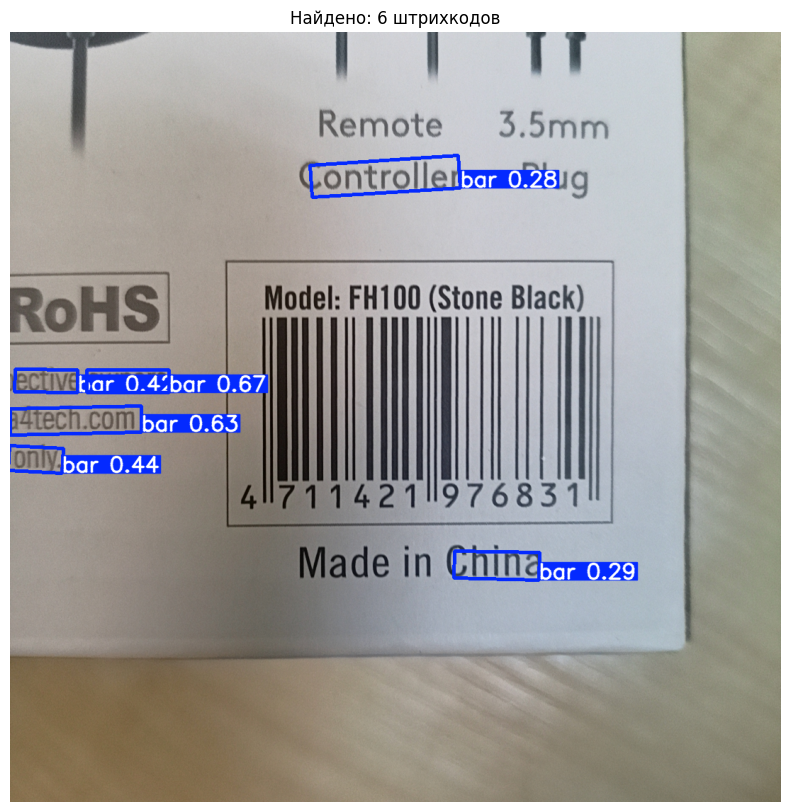

In [15]:
# Читаем изображение
image = cv2.imread(test_path)
print(f"Размер фото: {image.shape[1]}×{image.shape[0]} px")

# Детекция
results = model(test_path, conf=0.25)
boxes = results[0].obb
print(f"Найдено штрихкодов: {len(boxes)}")

# Покажем результат
annotated = results[0].plot()
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Найдено: {len(boxes)} штрихкодов")
plt.show()

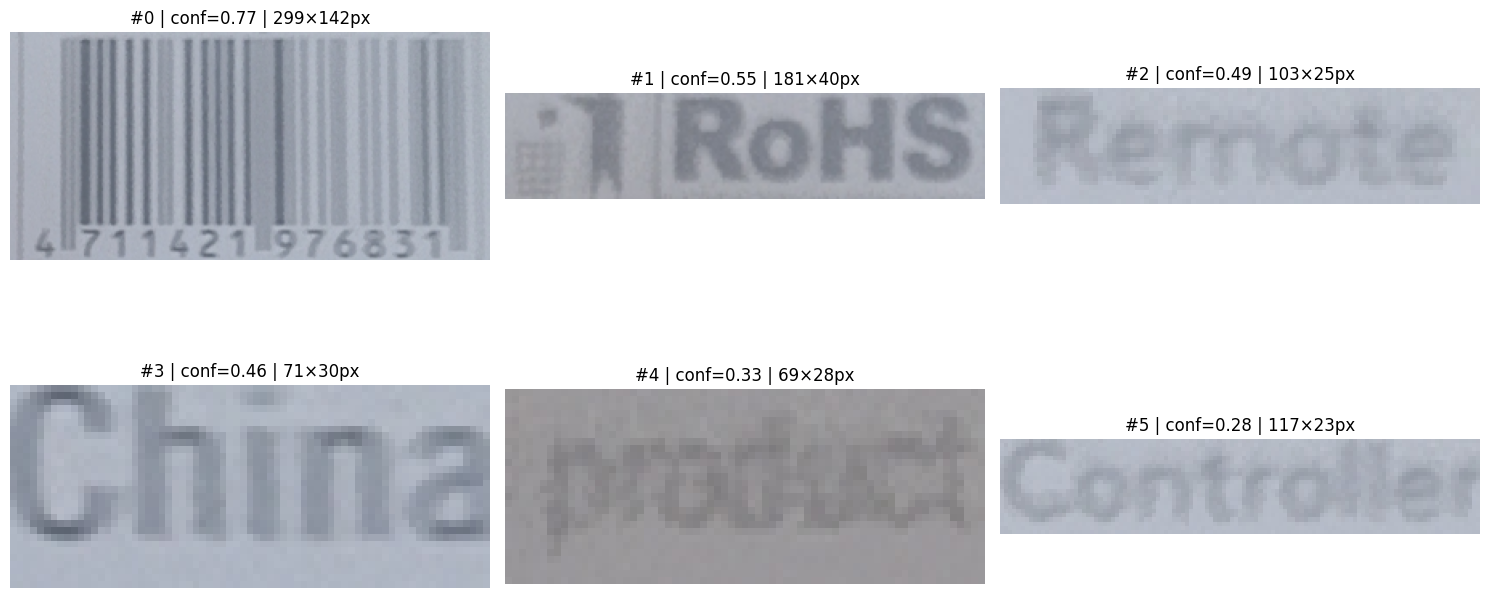

In [11]:
h_img, w_img = image.shape[:2]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i in range(min(6, len(boxes))):
    conf = float(boxes[i].conf[0])
    xyxy = boxes[i].xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, xyxy)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_img, x2), min(h_img, y2)

    crop = image[y1:y2, x1:x2]

    axes[i].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f"#{i} | conf={conf:.2f} | {x2-x1}×{y2-y1}px")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [12]:
def try_read(crop):
    """Возвращает текст штрихкода или None"""
    # Варианты увеличения
    for scale in [1, 2, 4]:
        if scale == 1:
            img = crop
        else:
            img = cv2.resize(crop, None, fx=scale, fy=scale)

        # CLAHE
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        l_enh = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)

        # Gray
        gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
        result = decode(gray)
        if result:
            return result[0].data.decode('utf-8')

        # Binary
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        result = decode(binary)
        if result:
            return result[0].data.decode('utf-8')

    return None


print("=" * 60)
print("ЧТЕНИЕ ШТРИХКОДОВ")
print("=" * 60)

decoded = []
for i, box in enumerate(boxes):
    conf = float(box.conf[0])
    if conf < 0.25:
        continue

    xyxy = box.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, xyxy)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_img, x2), min(h_img, y2)

    crop = image[y1:y2, x1:x2]
    text = try_read(crop)

    if text:
        print(f"#{i}: ✅ {text} | conf={conf:.2f} | {x2-x1}×{y2-y1}px")
    else:
        print(f"#{i}: ❌ | conf={conf:.2f} | {x2-x1}×{y2-y1}px")

    decoded.append({'index': i, 'text': text, 'bbox': [x1, y1, x2, y2], 'confidence': conf})

print(f"\nПрочитано: {sum(1 for d in decoded if d['text'])} / {len(decoded)}")

ЧТЕНИЕ ШТРИХКОДОВ
#0: ❌ | conf=0.77 | 299×142px
#1: ❌ | conf=0.55 | 181×40px
#2: ❌ | conf=0.49 | 103×25px
#3: ❌ | conf=0.46 | 71×30px
#4: ❌ | conf=0.33 | 69×28px
#5: ❌ | conf=0.28 | 117×23px

Прочитано: 0 / 6



0: 640x480 1 bar, 246.3ms
Speed: 33.7ms preprocess, 246.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)


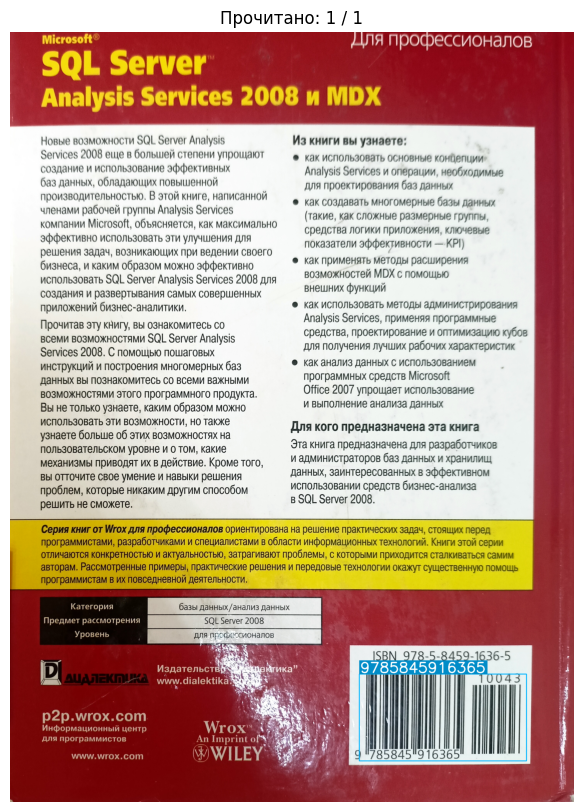


РЕЗУЛЬТАТЫ
  ✅ 9785845916365 | conf=0.85

Прочитано: 1 / 1


In [33]:
# ============================================================
# ФИНАЛЬНЫЙ ПАЙПЛАЙН: Детекция → Чтение → Визуализация
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pyzbar.pyzbar import decode

# ----------------------------------------------------------
# Функция чтения штрихкода из кропа (хард-режим)
# ----------------------------------------------------------
def try_read(crop):
    for scale in [1, 2, 4]:
        img = crop if scale == 1 else cv2.resize(crop, None, fx=scale, fy=scale)

        # CLAHE
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        l_enh = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)

        # Gray
        gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
        result = decode(gray)
        if result:
            return result[0].data.decode('utf-8')

        # Binary
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        result = decode(binary)
        if result:
            return result[0].data.decode('utf-8')

    return None


# ----------------------------------------------------------
# БЛОК 1: Детекция
# ----------------------------------------------------------
model = YOLO('/content/best.pt')
image = cv2.imread(test_path)
results = model(image, conf=0.25)
boxes = results[0].obb

# ----------------------------------------------------------
# БЛОК 2: Кроп → Контраст → Чтение
# ----------------------------------------------------------
h_img, w_img = image.shape[:2]
decoded = []

for i, box in enumerate(boxes):
    conf = float(box.conf[0])
    if conf < 0.25:
        continue

    xyxy = box.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, xyxy)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_img, x2), min(h_img, y2)

    crop = image[y1:y2, x1:x2]
    text = try_read(crop)

    decoded.append({
        'index': i,
        'text': text,
        'bbox': [x1, y1, x2, y2],
        'confidence': conf
    })

# ----------------------------------------------------------
# БЛОК 3: Визуализация (крупные подписи, бирюзовый цвет)
# ----------------------------------------------------------
result_image = image.copy()

for d in decoded:
    x1, y1, x2, y2 = d['bbox']

    # Бирюзовый если прочитан, красный если нет
    if d['text']:
        color = (255, 180, 0)      # бирюзовый в BGR
        color_bg = (200, 140, 0)   # потемнее для фона
    else:
        color = (0, 0, 255)        # красный
        color_bg = (0, 0, 180)     # тёмно-красный

    # Толстая рамка
    cv2.rectangle(result_image, (x1, y1), (x2, y2), color, 4)

    # Подпись
    label = d['text'] if d['text'] else f"??? {d['confidence']:.2f}"

    # Крупный шрифт
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2.5
    thickness = 5

    (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)

    # Фон под текст
    cv2.rectangle(result_image, (x1, y1 - th - 15), (x1 + tw + 10, y1), color_bg, -1)

    # Белый текст
    cv2.putText(result_image, label, (x1 + 5, y1 - 8),
                font, font_scale, (255, 255, 255), thickness)

# Показываем
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Прочитано: {sum(1 for d in decoded if d['text'])} / {len(decoded)}")
plt.show()

# ----------------------------------------------------------
# ИТОГ
# ----------------------------------------------------------
print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ")
print("=" * 50)
for d in decoded:
    if d['text']:
        print(f"  ✅ {d['text']} | conf={d['confidence']:.2f}")
    else:
        print(f"  ❌ не прочитан | conf={d['confidence']:.2f}")

print(f"\nПрочитано: {sum(1 for d in decoded if d['text'])} / {len(decoded)}")

In [34]:
import json
from datetime import datetime

# Формируем вывод API
api_output = {
    "timestamp": datetime.now().isoformat(),
    "image": test_path,
    "total_detected": len(decoded),
    "total_read": sum(1 for d in decoded if d['text']),
    "barcodes": [
        {
            "id": d['index'],
            "text": d['text'],
            "confidence": round(d['confidence'], 3),
            "bbox": d['bbox'],
            "status": "read" if d['text'] else "unreadable"
        }
        for d in decoded
    ]
}

# Выводим красиво
print(json.dumps(api_output, ensure_ascii=False, indent=2))

# Сохраняем в файл
with open('/content/api_output.json', 'w', encoding='utf-8') as f:
    json.dump(api_output, f, ensure_ascii=False, indent=2)
print("\n✅ Сохранено в api_output.json")

{
  "timestamp": "2026-05-18T11:34:52.611662",
  "image": "IMG20260518134333.jpg",
  "total_detected": 1,
  "total_read": 1,
  "barcodes": [
    {
      "id": 0,
      "text": "9785845916365",
      "confidence": 0.848,
      "bbox": [
        1813,
        3335,
        2681,
        3786
      ],
      "status": "read"
    }
  ]
}

✅ Сохранено в api_output.json


In [39]:
from google.colab import files
import cv2
import numpy as np
from ultralytics import YOLO
from pyzbar.pyzbar import decode
import json
from datetime import datetime

# Загружаем модель
model = YOLO('/content/best.pt')

# Загружаем видео
uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print(f"✅ Видео: {video_path}")

# ----------------------------------------------------------
# Функция чтения штрихкода
# ----------------------------------------------------------
def try_read(crop):
    for scale in [1, 2, 4]:
        img = crop if scale == 1 else cv2.resize(crop, None, fx=scale, fy=scale)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        l_enh = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)
        gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
        result = decode(gray)
        if result:
            return result[0].data.decode('utf-8')
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        result = decode(binary)
        if result:
            return result[0].data.decode('utf-8')
    return None

# ----------------------------------------------------------
# Функция проверки на размытие
# ----------------------------------------------------------
def is_blurry(crop, threshold=100):
    """True = размыто, False = чётко"""
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    return laplacian_var < threshold

# ----------------------------------------------------------
# Обработка видео
# ----------------------------------------------------------
results = model(video_path, stream=True, conf=0.5)  # порог 0.5

all_frames_output = []
read_barcodes = {}  # запоминаем прочитанные, чтобы не дублировать
frame_num = 0

for r in results:
    frame_num += 1
    image = r.orig_img
    boxes = r.obb

    if boxes is None or len(boxes) == 0:
        continue

    h_img, w_img = image.shape[:2]
    frame_decoded = []

    for i, box in enumerate(boxes):
        conf = float(box.conf[0])
        if conf < 0.5:
            continue

        xyxy = box.xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = map(int, xyxy)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w_img, x2), min(h_img, y2)

        crop = image[y1:y2, x1:x2]

        # Пропускаем размытые кропы
        if is_blurry(crop):
            continue

        # Пробуем прочитать
        text = try_read(crop)

        # Если прочитался и это новый штрихкод — выводим
        if text and text not in read_barcodes:
            read_barcodes[text] = frame_num
            print(f"🎯 Кадр {frame_num}: ✅ {text} | conf={conf:.2f}")

        frame_decoded.append({
            'text': text,
            'confidence': round(conf, 3),
            'bbox': [x1, y1, x2, y2]
        })

    if frame_decoded:
        all_frames_output.append({
            'frame': frame_num,
            'barcodes': frame_decoded
        })

# ----------------------------------------------------------
# ИТОГ
# ----------------------------------------------------------
print(f"\n{'='*50}")
print(f"Обработано кадров: {frame_num}")
print(f"Найдено уникальных штрихкодов: {len(read_barcodes)}")
print(f"{'='*50}")
for text, first_frame in read_barcodes.items():
    print(f"  ✅ {text} | кадр {first_frame}")

# JSON
print(f"\nJSON (первые 3 кадра):")
print(json.dumps(all_frames_output[:3], ensure_ascii=False, indent=2))

Saving VID20260518144201.mp4 to VID20260518144201 (1).mp4
✅ Видео: VID20260518144201 (1).mp4

video 1/1 (frame 1/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 159.5ms
video 1/1 (frame 2/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 162.8ms
video 1/1 (frame 3/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 158.6ms
video 1/1 (frame 4/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 152.8ms
video 1/1 (frame 5/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 157.0ms
video 1/1 (frame 6/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 175.2ms
video 1/1 (frame 7/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 148.5ms
video 1/1 (frame 8/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 150.3ms
video 1/1 (frame 9/88) /content/VID20260518144201 (1).mp4: 640x384 (no detections), 155.8ms
video 1/1 (frame 10/88) /content/VID20260518144201 (1).mp4: 640x384 (no detect

In [42]:
# ----------------------------------------------------------
# СОХРАНЯЕМ ВИДЕО: рамка появляется в момент чтения и держится 1 сек
# ----------------------------------------------------------

# Открываем исходное видео
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('/content/output_video.mp4', fourcc, fps, (width, height))

# Длительность показа рамки в кадрах (1 секунда)
hold_frames = int(fps)

# Собираем словарь: {text: {'bbox': [...], 'first_frame': N, 'conf': ...}}
memory = {}
for f in all_frames_output:
    for d in f['barcodes']:
        if d['text'] and d['text'] not in memory:
            memory[d['text']] = {
                'bbox': d['bbox'],
                'first_frame': f['frame'],
                'confidence': d['confidence']
            }

# Читаем видео по кадрам
frame_num = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_num += 1

    # Рисуем только те штрихкоды, которые уже обнаружены и не старше 1 секунды
    for text, info in memory.items():
        first_frame = info['first_frame']

        # Пропускаем, если ещё не дошли до кадра обнаружения
        if frame_num < first_frame:
            continue

        # Пропускаем, если прошло больше 1 секунды
        if frame_num > first_frame + hold_frames:
            continue

        x1, y1, x2, y2 = info['bbox']

        # Бирюзовая рамка
        color = (255, 180, 0)
        color_bg = (200, 140, 0)

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)

        # Подпись
        label = text
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.6
        thickness = 2
        (tw, th), _ = cv2.getTextSize(label, font, font_scale, thickness)
        cv2.rectangle(frame, (x1, y1 - th - 8), (x1 + tw + 6, y1), color_bg, -1)
        cv2.putText(frame, label, (x1 + 3, y1 - 4), font, font_scale, (255, 255, 255), thickness)

    out.write(frame)

cap.release()
out.release()
print("✅ Видео сохранено: /content/output_video.mp4")

# Скачать
from google.colab import files
files.download('/content/output_video.mp4')

✅ Видео сохранено: /content/output_video.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
# Копируем модель с Google Диска
!cp /content/drive/MyDrive/barcode_models/best.pt /content/
model = YOLO('/content/best.pt')
print("✅ Модель загружена")

# Загружаем тестовое фото с компьютера
uploaded = files.upload()
test_path = list(uploaded.keys())[0]
print(f"✅ Фото: {test_path}")

✅ Модель загружена


Saving Screenshot_2026-05-18-14-50-29-15_c1ebbaff44ba152fb7f7c2e1f7129fd1.jpg to Screenshot_2026-05-18-14-50-29-15_c1ebbaff44ba152fb7f7c2e1f7129fd1.jpg
✅ Фото: Screenshot_2026-05-18-14-50-29-15_c1ebbaff44ba152fb7f7c2e1f7129fd1.jpg



0: 640x288 4 bars, 153.1ms
Speed: 7.9ms preprocess, 153.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 288)


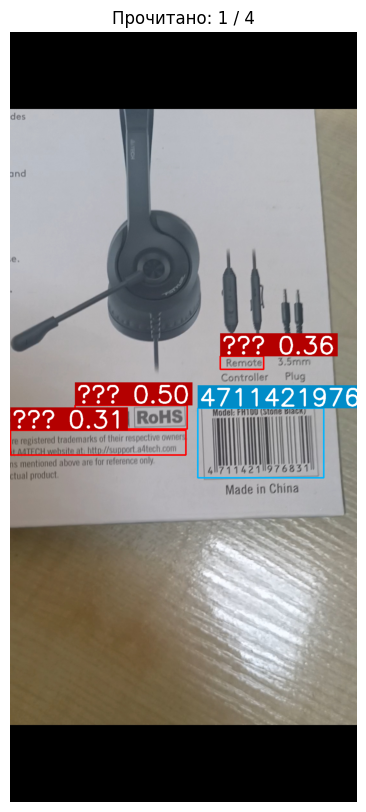


РЕЗУЛЬТАТЫ
  ✅ 4711421976831 | conf=0.79
  ❌ не прочитан | conf=0.50
  ❌ не прочитан | conf=0.36
  ❌ не прочитан | conf=0.31

Прочитано: 1 / 4


In [38]:
# ============================================================
# ФИНАЛЬНЫЙ ПАЙПЛАЙН: Детекция → Чтение → Визуализация
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pyzbar.pyzbar import decode

# ----------------------------------------------------------
# Функция чтения штрихкода из кропа (хард-режим)
# ----------------------------------------------------------
def try_read(crop):
    for scale in [1, 2, 4]:
        img = crop if scale == 1 else cv2.resize(crop, None, fx=scale, fy=scale)

        # CLAHE
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        l_enh = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)

        # Gray
        gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
        result = decode(gray)
        if result:
            return result[0].data.decode('utf-8')

        # Binary
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        result = decode(binary)
        if result:
            return result[0].data.decode('utf-8')

    return None


# ----------------------------------------------------------
# БЛОК 1: Детекция
# ----------------------------------------------------------
model = YOLO('/content/best.pt')
image = cv2.imread(test_path)
results = model(image, conf=0.25)
boxes = results[0].obb

# ----------------------------------------------------------
# БЛОК 2: Кроп → Контраст → Чтение
# ----------------------------------------------------------
h_img, w_img = image.shape[:2]
decoded = []

for i, box in enumerate(boxes):
    conf = float(box.conf[0])
    if conf < 0.25:
        continue

    xyxy = box.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, xyxy)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_img, x2), min(h_img, y2)

    crop = image[y1:y2, x1:x2]
    text = try_read(crop)

    decoded.append({
        'index': i,
        'text': text,
        'bbox': [x1, y1, x2, y2],
        'confidence': conf
    })

# ----------------------------------------------------------
# БЛОК 3: Визуализация (крупные подписи, бирюзовый цвет)
# ----------------------------------------------------------
result_image = image.copy()

for d in decoded:
    x1, y1, x2, y2 = d['bbox']

    # Бирюзовый если прочитан, красный если нет
    if d['text']:
        color = (255, 180, 0)      # бирюзовый в BGR
        color_bg = (200, 140, 0)   # потемнее для фона
    else:
        color = (0, 0, 255)        # красный
        color_bg = (0, 0, 180)     # тёмно-красный

    # Толстая рамка
    cv2.rectangle(result_image, (x1, y1), (x2, y2), color, 4)

    # Подпись
    label = d['text'] if d['text'] else f"??? {d['confidence']:.2f}"

    # Крупный шрифт
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 2.5
    thickness = 5

    (tw, th), baseline = cv2.getTextSize(label, font, font_scale, thickness)

    # Фон под текст
    cv2.rectangle(result_image, (x1, y1 - th - 15), (x1 + tw + 10, y1), color_bg, -1)

    # Белый текст
    cv2.putText(result_image, label, (x1 + 5, y1 - 8),
                font, font_scale, (255, 255, 255), thickness)

# Показываем
plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Прочитано: {sum(1 for d in decoded if d['text'])} / {len(decoded)}")
plt.show()

# ----------------------------------------------------------
# ИТОГ
# ----------------------------------------------------------
print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ")
print("=" * 50)
for d in decoded:
    if d['text']:
        print(f"  ✅ {d['text']} | conf={d['confidence']:.2f}")
    else:
        print(f"  ❌ не прочитан | conf={d['confidence']:.2f}")

print(f"\nПрочитано: {sum(1 for d in decoded if d['text'])} / {len(decoded)}")

In [43]:
from ultralytics import YOLO

model = YOLO('/content/best.pt')
model.export(format='tflite', imgsz=640)
print("✅ TFLite модель готова: /content/best_saved_model/best_float32.tflite")

# Скачать
from google.colab import files
files.download('/content/best_saved_model/best_float32.tflite')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11n-obb summary (fused): 110 layers, 2,653,918 parameters, 0 gradients, 6.6 GFLOPs

PyTorch: starting from '/content/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 6, 8400) (5.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 949ms
Prepared 4 packages in 5.67s
Installed 4 packages in 1.86s
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 10.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
O

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
import cv2
from pyzbar.pyzbar import decode

img = cv2.imread("barcode_crop_onlycode.jpg")
# Обрежь примерно где штрихкод
crop = img[y1:y2, x1:x2]  # примерные координаты
for scale in [1, 2, 4]:
    scaled = cv2.resize(crop, None, fx=scale, fy=scale)
    result = decode(scaled)
    if result:
        print("Читается:", result[0].data.decode())
        break
else:
    print("Не читается даже на Python")

ModuleNotFoundError: No module named 'pyzbar'

Saving test_frame (4).jpg to test_frame (4).jpg
Размер: 1088×1088 px

0: 640x640 3 bars, 314.1ms
Speed: 11.0ms preprocess, 314.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Найдено: 3
#0: ❌ | conf=0.83 | 193×97px
#1: ❌ | conf=0.55 | 122×35px
#2: ✅ 4711421976831 | conf=0.35 | 182×44px

Прочитано: 1 / 3


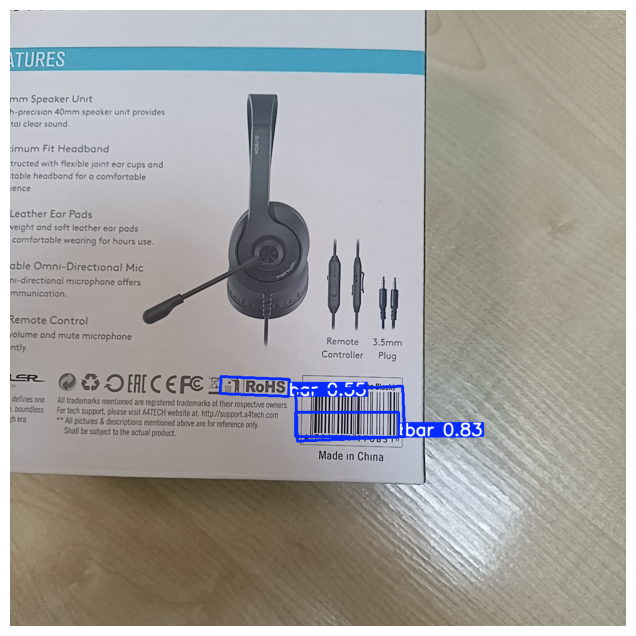

In [16]:
import cv2
from ultralytics import YOLO
from pyzbar.pyzbar import decode
from google.colab import files
import matplotlib.pyplot as plt

# Загружаем фото
uploaded = files.upload()
test_path = list(uploaded.keys())[0]

# Загружаем модель
model = YOLO('/content/best.pt')  # или путь к твоей модели

# Читаем и показываем
image = cv2.imread(test_path)
print(f"Размер: {image.shape[1]}×{image.shape[0]} px")

# Инференс
results = model(image, conf=0.25)
boxes = results[0].obb
print(f"Найдено: {len(boxes)}")

def try_read(crop):
    for scale in [1, 2, 4]:
        img = crop if scale == 1 else cv2.resize(crop, None, fx=scale, fy=scale)
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        l_enh = clahe.apply(l)
        enhanced = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)
        gray = cv2.cvtColor(enhanced, cv2.COLOR_BGR2GRAY)
        result = decode(gray)
        if result:
            return result[0].data.decode('utf-8')
        _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        result = decode(binary)
        if result:
            return result[0].data.decode('utf-8')
    return None

h_img, w_img = image.shape[:2]
decoded = []

for i, box in enumerate(boxes):
    conf = float(box.conf[0])
    if conf < 0.25:
        continue

    xyxy = box.xyxy[0].cpu().numpy()
    x1, y1, x2, y2 = map(int, xyxy)
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w_img, x2), min(h_img, y2)

    crop = image[y1:y2, x1:x2]
    text = try_read(crop)

    if text:
        print(f"#{i}: ✅ {text} | conf={conf:.2f} | {x2-x1}×{y2-y1}px")
    else:
        print(f"#{i}: ❌ | conf={conf:.2f} | {x2-x1}×{y2-y1}px")

    decoded.append({'index': i, 'text': text, 'bbox': [x1, y1, x2, y2], 'confidence': conf})

print(f"\nПрочитано: {sum(1 for d in decoded if d['text'])} / {len(decoded)}")

# Покажем результат
result_image = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()